# Feature Engineering Notebook
This notebook includes a comprehensive pipeline for data preprocessing and feature engineering on the dataset at `data/processed/main/merged.csv`.

## Goals

- Load and inspect the merged dataset
- Clean missing, duplicated, and inconsistent values
- Standardize column names and data types
- Handle outliers and noisy records
- Encode categorical variables for modeling
- Scale or transform numerical features where needed
- Create new features from existing data
- Reduce feature redundancy and improve data quality
- Save the processed dataset for downstream modeling

## Preprocessing Pipeline
This section performs, in order:
1. Drop leakage and useless features 
2. Create derived features (`amenities_count`, `avg_rating`)
3. Handle missing values (drop high-missing columns, numeric=median, categorical=mode)
4. Convert boolean-like values to 0/1
5. Remove outliers (IQR method)
6. One-hot encode categorical columns and save engineered dataset
7. Plot final correlation heatmap

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
# Resolve paths robustly whether kernel CWD is project root or Notebooks/
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

input_path = project_root / "data" / "processed" / "main" / "merged.csv"
output_path = project_root / "data" / "processed" / "main" / "feature_engineered.csv"

In [24]:
# Load merged dataset
df = pd.read_csv(input_path, low_memory=False)

print(f"Loaded shape: {df.shape}")
print(f"Input path: {input_path}")
df.head(3)

Loaded shape: (47813, 65)
Input path: c:\Users\RUSHIKESH\Desktop\Airbnb Project\data\processed\main\merged.csv


,listing_id,listing_name,listing_type,room_type,cover_photo_url,photos_count,host_id,host_name,cohost_ids,cohost_names,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,geographic_zone,distance_from_city_center,city_population
0,1754773.0,Centrally located in Accra with Chocolates to go!,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/ec7fdf2a-0...,34.0,9220860,Yaaba,NaN,NaN,...,199.7,29.7,304.6,45,31,45,90.0,Africa,1.924028,1963264
1,5059526.0,NEW! Luxury Studio at Embassy Gardens,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/a1c70987-6...,14.0,26125588,Alex,NaN,NaN,...,146.9,0.0,0.0,17,0,73,90.0,Africa,3.829708,44000
2,5296203.0,Studio Apt. in the center of Osu,Entire bungalow,entire_home,https://a0.muscache.com/im/pictures/68216885/b...,10.0,27429560,Linda,NaN,NaN,...,70.7,12.9,132.5,13,42,77,90.0,Africa,0.423014,44000


In [25]:
df.describe()

,listing_id,photos_count,host_id,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,l90d_revpar,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,distance_from_city_center,city_population
count,4.781200e+04,47587.000000,4.781300e+04,47813.000000,47813.000000,41204.000000,38884.000000,47332.000000,47777.000000,46221.000000,...,47813.000000,4.781300e+04,47813.000000,4.781300e+04,47813.00000,47813.000000,47813.00000,47812.0,47813.000000,4.781300e+04
mean,7.040707e+16,29.929035,9.507820e+07,21.464127,-0.562846,4.313198,1.897979,2.484324,1.341702,6.953917,...,35.762205,1.381592e+04,15.998670,6.811296e+03,22.00845,13.886098,67.99155,90.0,3.070931,7.725804e+05
std,2.463897e+17,21.249050,1.348580e+08,26.724544,73.511140,2.674183,1.254535,2.049747,1.135360,35.425103,...,69.857304,1.206788e+05,55.888706,9.342185e+04,23.48372,24.102536,23.48372,0.0,3.660460,1.642746e+06
min,6.000000e+00,0.000000,2.900000e+01,-45.076700,-157.861400,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000,0.00000,90.0,0.003453,5.000000e+03
25%,3.298538e+06,16.000000,7.101186e+06,6.218400,-71.249400,2.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000,52.00000,90.0,0.884532,1.900000e+04
50%,1.405069e+07,25.000000,3.386090e+07,30.410300,10.309800,4.000000,2.000000,2.000000,1.000000,2.000000,...,12.000000,6.730000e+01,0.000000,0.000000e+00,14.00000,0.000000,76.00000,90.0,1.815468,9.298700e+04
75%,2.933034e+07,37.000000,1.263438e+08,41.049600,32.622400,6.000000,2.000000,3.000000,2.000000,3.000000,...,41.900000,4.316000e+02,5.800000,2.450000e+01,38.00000,20.000000,90.00000,90.0,3.783893,7.809950e+05
max,1.340000e+18,493.000000,7.374132e+08,59.407200,174.847700,16.000000,41.000000,50.000000,38.000000,999.000000,...,2090.500000,6.361059e+06,2148.400000,7.032681e+06,90.00000,90.000000,90.00000,90.0,47.745695,1.570160e+07


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47813 entries, 0 to 47812
Data columns (total 65 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   47812 non-null  float64
 1   listing_name                 47810 non-null  str    
 2   listing_type                 47813 non-null  str    
 3   room_type                    47813 non-null  str    
 4   cover_photo_url              47587 non-null  str    
 5   photos_count                 47587 non-null  float64
 6   host_id                      47813 non-null  int64  
 7   host_name                    47435 non-null  str    
 8   cohost_ids                   11031 non-null  str    
 9   cohost_names                 11031 non-null  str    
 10  superhost                    47813 non-null  bool   
 11  latitude                     47813 non-null  float64
 12  longitude                    47813 non-null  float64
 13  guests                     

### Step 1: Handle Missing Values
1. Drop columns with more than 40% missing values.
2. Impute numeric columns with median.
3. Impute categorical columns with mode.

In [27]:
df_clean = df.copy()


missing_ratio = df_clean.isna().mean()
too_missing_cols = missing_ratio[missing_ratio > 0.50].index.tolist()
df_clean = df_clean.drop(columns=too_missing_cols, errors="ignore")


numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()


for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())


for col in categorical_cols:
    if df_clean[col].isna().any():
        mode_series = df_clean[col].mode(dropna=True)
        if not mode_series.empty:
            df_clean[col] = df_clean[col].fillna(mode_series.iloc[0])

print(f"Dropped columns with >50% missing values: {too_missing_cols}")
print(f"Dropped columns count: {len(too_missing_cols)}")
print(f"Shape after Step 1: {df_clean.shape}")

Dropped columns with >50% missing values: ['cohost_ids', 'cohost_names', 'instant_book']
Dropped columns count: 3
Shape after Step 1: (47813, 62)


### Step 2: Drop Leakage and Useless Features
Remove target-leaking metrics and non-informative columns

In [ ]:
# 1. Identifiers / media / text
# City and Country name won't going to be useful in this case
drop_always = [
    'listing_id', 'cover_photo_url', 'host_id', 'host_name', 'listing_name', 'cohost_names', 'currency',
    'city', 'country', 'country_code'
 ]


# 2. All l90d columns (keep ttm)
drop_l90d = [col for col in df_clean.columns if col.startswith('l90d_')]


# 3. Native duplicate currency columns (keeping non-native)
drop_native = [col for col in df_clean.columns if col.endswith('_native')] 

drop_leakage = ['ttm_revpar', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_adjusted_revpar']

# Combine all and drop
cols_to_drop = drop_always + drop_l90d + drop_native + drop_leakage
cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns] 


original_shape = df_clean.shape
df_clean = df_clean.drop(columns=cols_to_drop)


print(f"Original shape : {original_shape}")
print(f"After dropping : {df_clean.shape}")
print(f"Dropped {len(cols_to_drop)} columns")
print(f"\nRemaining columns:\n{df_clean.columns.tolist()}")

Original shape : (47813, 62)
After dropping : (47813, 33)
Dropped 33 columns

Remaining columns:
['listing_type', 'room_type', 'photos_count', 'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities', 'professional_management', 'min_nights', 'cancellation_policy', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_avg_rate', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days', 'geographic_zone', 'distance_from_city_center', 'city_population']


### Step 3: Create Derived Features
Create `amenities_count` from the amenities list and combine rating columns into `avg_rating`.

In [29]:
# Ensure project root is in sys.path
import sys

project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from scripts.data.main.amenties_utility import create_amenity_features
from scripts.data.main.listing_type_utils import categorize_listing

amenity_features = create_amenity_features(df_clean['amenities'])
df_clean = pd.concat([df_clean, amenity_features], axis=1)
df_clean = df_clean.drop(columns=['amenities'], errors="ignore")

# avg_rating: average of rating_* columns, then drop originals
rating_cols = [
    c for c in df_clean.columns
    if c.startswith("rating_")
]
if rating_cols:
    df_clean["avg_rating"] = df_clean[rating_cols].mean(axis=1, skipna=True)
    df_clean = df_clean.drop(columns=rating_cols, errors="ignore")

# map list type to broader category
df_clean['listing_type'] = df_clean['listing_type'].apply(categorize_listing)

# ===== BOOST LUXURY SCORE FOR LUXURY LISTING TYPES =====
# Add significant points to luxury_score when listing_type is luxury_unique
# This helps the model better understand and differentiate luxury listings
luxury_bonus = 8  # Add 8 points (max amenity-based score is ~12, so this is substantial)
df_clean.loc[df_clean['listing_type'] == 'luxury_unique', 'luxury_score'] += luxury_bonus

print(f"Created amenities_count and avg_rating. Shape after Step 2: {df_clean.shape}")

Created amenities_count and avg_rating. Shape after Step 2: (47813, 45)


### Step 4: Convert Boolean-like Values to 0/1
Convert TRUE/FALSE, yes/no, Y/N style categorical flags into numeric binary values.

In [30]:
bool_like_map = {
    "TRUE": 1, "FALSE": 0,
    "true": 1, "false": 0,
    "True": 1, "False": 0,
    True: 1, False: 0,
    "YES": 1, "NO": 0,
    "yes": 1, "no": 0,
    "Y": 1, "N": 0
}

for col in df_clean.columns:
    if df_clean[col].dtype == bool:
        df_clean[col] = df_clean[col].astype(int)
        continue


    if df_clean[col].dtype == object:
        s = df_clean[col].dropna().astype(str).str.strip()
        if len(s) == 0:
            continue
        unique_vals = set(s.unique())
        if unique_vals.issubset({"TRUE", "FALSE", "true", "false", "True", "False", "YES", "NO", "yes", "no", "Y", "N"}):
            df_clean[col] = df_clean[col].map(bool_like_map)


print(f"Boolean conversion complete. Shape after Step 4: {df_clean.shape}")

Boolean conversion complete. Shape after Step 4: (47813, 45)


### Step 5: Remove Outliers (After Imputation)
Apply IQR-based row filtering on non-binary numeric columns after missing-value handling.

In [31]:
import sys

# Ensure project root is importable when notebook CWD is Notebooks/
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


from scripts.data.main.outlier_analysis import analyze_outliers_iqr

outlier_df = analyze_outliers_iqr(df_clean)

print(f"Analyzed {len(outlier_df)} non-binary numeric features.")
display(outlier_df)

Analyzed 30 non-binary numeric features.


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,city_population,-1.123992e+06,1.923988e+06,5843,12.22
1,min_nights,-2.000000e+00,6.000000e+00,5652,11.82
2,distance_from_city_center,-3.464509e+00,8.132934e+00,3686,7.71
3,cleaning_fee,-7.200000e+01,1.200000e+02,3584,7.50
4,bedrooms,-5.000000e-01,3.500000e+00,3426,7.17
5,rarity_score,-1.933413e-03,6.365216e-03,3339,6.98
6,num_reviews,-1.965000e+02,3.995000e+02,3333,6.97
7,ttm_blocked_days,-9.450000e+01,1.575000e+02,3308,6.92
8,ttm_avg_rate,-1.307000e+02,3.525000e+02,3277,6.85
9,family_count,-1.500000e+00,2.500000e+00,2864,5.99


In [32]:
import numpy as np
import pandas as pd


# 1. REMOVE INVALID ROWS ONLY (KEEP VALID HIGH-PRICE LISTINGS)
invalid_conditions = (
    (df_clean["min_nights"] < 0) |
    (df_clean["distance_from_city_center"] < 0) |
    (df_clean["cleaning_fee"] < 0) |
    (df_clean["bedrooms"] < 0) |
    (df_clean["beds"] < 0) |
    (df_clean["baths"] < 0) |
    (df_clean["guests"] < 0) |
    (df_clean["num_reviews"] < 0) |
    (df_clean["photos_count"] < 0)
)

rows_before_invalid = len(df_clean)
df_clean = df_clean[~invalid_conditions].copy()
print(f"Removed {rows_before_invalid - len(df_clean)} invalid rows (negative values).")


# 2. FEATURE OUTLIER ROW FILTERING (NO TARGET HARDCUT)
# Keep ttm_avg_rate distribution intact; only filter extreme feature errors.
print("\n" + "=" * 80)
print("FEATURE OUTLIER ROW REMOVAL (IQR-Based, Target Preserved)")
print("=" * 80)

outlier_features = {
    "distance_from_city_center": 3.0,
    "min_nights": 3.0,
    "cleaning_fee": 3.0,
    "bedrooms": 3.0,
    "beds": 3.0,
    "baths": 3.0,
    "num_reviews": 3.0,
    "photos_count": 3.0,
    "ttm_blocked_days": 3.0,
}

rows_to_keep = pd.Series([True] * len(df_clean), index=df_clean.index)

for col, iqr_mult in outlier_features.items():
    if col not in df_clean.columns:
        continue

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        print(f"  {col}: skipped (IQR=0)")
        continue

    lower_bound = Q1 - iqr_mult * IQR
    upper_bound = Q3 + iqr_mult * IQR

    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = 100 * outlier_count / len(df_clean)

    rows_to_keep = rows_to_keep & ~outlier_mask

    print(f"  {col}: {outlier_count} outliers ({outlier_pct:.2f}%) | bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

df_before = len(df_clean)
df_clean = df_clean[rows_to_keep].copy()
rows_removed = df_before - len(df_clean)
rows_pct_removed = 100 * rows_removed / df_before

print(f"\nRemoved {rows_removed} rows ({rows_pct_removed:.2f}%) with feature anomalies.")
print(f"Remaining rows: {len(df_clean)}")
print("\nTarget distribution retained (no explicit ttm_avg_rate cutoff):")
print(df_clean["ttm_avg_rate"].describe())
print(f"Final shape after Step 5: {df_clean.shape}")

Removed 0 invalid rows (negative values).

FEATURE OUTLIER ROW REMOVAL (IQR-Based, Target Preserved)
  distance_from_city_center: 1410 outliers (2.95%) | bounds: [-7.81, 12.48]
  min_nights: 4477 outliers (9.36%) | bounds: [-5.00, 9.00]
  cleaning_fee: 1516 outliers (3.17%) | bounds: [-144.00, 192.00]
  bedrooms: 639 outliers (1.34%) | bounds: [-2.00, 5.00]
  beds: 602 outliers (1.26%) | bounds: [-5.00, 9.00]
  baths: 547 outliers (1.14%) | bounds: [-2.00, 5.00]
  num_reviews: 929 outliers (1.94%) | bounds: [-420.00, 623.00]
  photos_count: 606 outliers (1.27%) | bounds: [-47.00, 100.00]
  ttm_blocked_days: 577 outliers (1.21%) | bounds: [-189.00, 252.00]

Removed 9728 rows (20.35%) with feature anomalies.
Remaining rows: 38085

Target distribution retained (no explicit ttm_avg_rate cutoff):
count    38085.000000
mean       124.362106
std        123.029867
min          8.600000
25%         48.200000
50%         89.200000
75%        159.500000
max       3525.000000
Name: ttm_avg_rate, d

In [33]:
outlier_df = analyze_outliers_iqr(df_clean)

print(f"Analyzed {len(outlier_df)} non-binary numeric features.")
display(outlier_df)

Analyzed 30 non-binary numeric features.


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,baths,2.500000e-01,2.250000e+00,8931,23.45
1,city_population,-1.283540e+06,2.192200e+06,4026,10.57
2,ttm_blocked_days,-8.100000e+01,1.350000e+02,2741,7.20
3,rarity_score,-1.822463e-03,6.154332e-03,2558,6.72
4,distance_from_city_center,-3.232850e+00,7.766469e+00,2277,5.98
5,family_count,-1.500000e+00,2.500000e+00,2161,5.67
6,num_reviews,-1.990000e+02,4.090000e+02,2078,5.46
7,ttm_avg_rate,-1.187500e+02,3.264500e+02,2045,5.37
8,cleaning_fee,-6.900000e+01,1.150000e+02,2024,5.31
9,bedrooms,-5.000000e-01,3.500000e+00,1696,4.45



STEP 5 IMPACT ON TARGET DISTRIBUTION


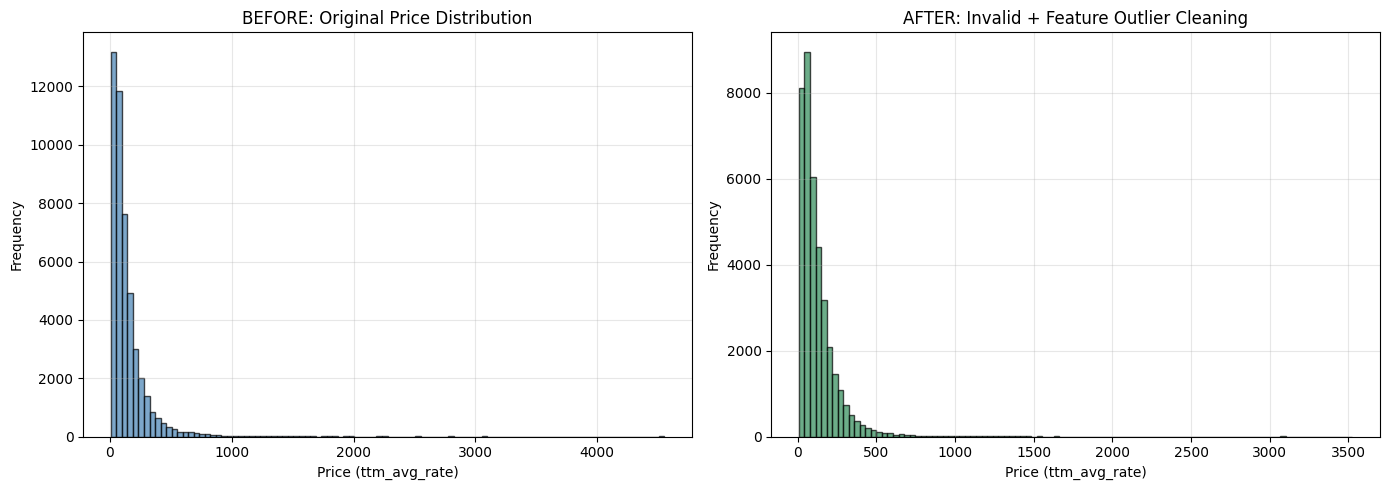


Data quality summary:
  Rows removed: 9728
  Rows remaining: 38085
  Price range: $8.60 - $3525.00
  Price mean: $124.36
  Price std: $123.03
  Listings in top 5% price band (>= $335.20): 1907

No explicit high-price hard cutoff applied.


In [34]:
# Visualize target distribution before vs after Step 5 (without target hard cutoff)
print("\n" + "=" * 80)
print("STEP 5 IMPACT ON TARGET DISTRIBUTION")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
axes[0].hist(df['ttm_avg_rate'], bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Price (ttm_avg_rate)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BEFORE: Original Price Distribution')
axes[0].grid(True, alpha=0.3)

# After cleaning
axes[1].hist(df_clean['ttm_avg_rate'], bins=100, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Price (ttm_avg_rate)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('AFTER: Invalid + Feature Outlier Cleaning')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

q95 = df_clean['ttm_avg_rate'].quantile(0.95)
print("\nData quality summary:")
print(f"  Rows removed: {len(df) - len(df_clean)}")
print(f"  Rows remaining: {len(df_clean)}")
print(f"  Price range: ${df_clean['ttm_avg_rate'].min():.2f} - ${df_clean['ttm_avg_rate'].max():.2f}")
print(f"  Price mean: ${df_clean['ttm_avg_rate'].mean():.2f}")
print(f"  Price std: ${df_clean['ttm_avg_rate'].std():.2f}")
print(f"  Listings in top 5% price band (>= ${q95:.2f}): {(df_clean['ttm_avg_rate'] >= q95).sum()}")
print("\nNo explicit high-price hard cutoff applied.")

### Optional Tail-Price Accuracy Fixes (Recommended)

If expensive listings are still under-predicted in training, try these in modeling instead of deleting high-price rows:

1. Use sample weights to upweight top-price samples (for example top 10% of `ttm_avg_rate`).
2. Train a two-stage model: classify luxury/non-luxury, then use separate regressors.
3. Keep this notebook as-is for target retention, and tune model loss/weights in training.
4. Report metrics by price bands (`p50`, `p75`, `p90`, `p95`) in addition to overall RMSE/MAE.

### Step 6: Encoding Categorical Features
- Use One Hot Encoding for nomical categorical features
- Use Label Encoding for ordinal categorical features

In [35]:
# Use the cleaned dataframe before one-hot encoding
source_df = df_clean if "df_clean" in globals() else df_clean

categorical_cols = source_df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print(f"Categorical columns found: {len(categorical_cols)}")
print(categorical_cols)

unique_counts = source_df[categorical_cols].nunique(dropna=False).sort_values(ascending=False)

print("\nUnique values per categorical column:")
for col, n_unique in unique_counts.items():
    print(f"{col}: {n_unique}")

Categorical columns found: 4
['listing_type', 'room_type', 'cancellation_policy', 'geographic_zone']

Unique values per categorical column:
cancellation_policy: 12
listing_type: 11
geographic_zone: 6
room_type: 4


In [36]:
df['room_type'].unique()

<StringArray>
['entire_home', 'private_room', 'hotel_room', 'shared_room']
Length: 4, dtype: str

In [37]:
df_encoded = df_clean.copy()

# 1. Ordinal Encoding — cancellation_policy
cancellation_order = {
    'Full Refundable Until Check-in': 0,
    'Full Refundable Until 24 Hours Before Check-in': 1,
    'Full Refundable Until 72 Hours Before Check-in': 2,
    'Refundable': 3,
    'Flexible': 4,
    'Moderate': 5,
    'Limited': 6,
    'Firm': 7,
    'Strict': 8,
    'Non-refundable': 9,
    'Super Strict 30 Days': 10,
    'Super Strict 60 Days': 11
}

df_encoded['cancellation_policy'] = df_encoded['cancellation_policy'].str.strip().map(cancellation_order)

# 2. One-Hot Encoding — geographic_zone, room_type
df_encoded = pd.get_dummies(df_encoded, columns=['listing_type', 'room_type', 'geographic_zone'])


# 3. Verify
print(df_encoded.shape)
print(df_encoded.dtypes[df_encoded.dtypes == 'object']) 

(38085, 63)
Series([], dtype: object)


### Step 7: Applying Transformations
Several features have heavy right skew, apply log transformation

In [38]:
import numpy as np

log_cols = [
    'ttm_avg_rate',
    'ttm_revenue',
    'num_reviews', 
    'distance_from_city_center',
]

for col in log_cols:
    if col in df_encoded.columns:
        df_encoded[col] = np.log1p(df_encoded[col])  # log1p handles 0 values safely

print(f"✓ Applied log transformation to: {log_cols}")

✓ Applied log transformation to: ['ttm_avg_rate', 'ttm_revenue', 'num_reviews', 'distance_from_city_center']


### Step 8: Drop Duplicate Rows

In [39]:
df_encoded = df_encoded.drop_duplicates()

### Step 9: Correlation Analysis
- Drop highly correlated features to reduce redundancy
- Plot a correlation heatmap on the top-variance numeric features in the final engineered dataset for readability.

In [40]:
corr_matrix = df_encoded.select_dtypes(include=[np.number]).corr().abs()

# Find all pairs with correlation > 0.7
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row) for col in upper.columns 
             for row in upper.index 
             if upper[col][row] > 0.7]

print(high_corr)

[('bedrooms', 'guests'), ('beds', 'guests'), ('ttm_available_days', 'ttm_reserved_days')]


In [41]:
drop_correlated = ['ttm_revpar', 'ttm_available_days', 'ttm_reserved_days']

df_encoded = df_encoded.drop(columns=drop_correlated, errors='ignore')
print(df_encoded.shape)

(37293, 61)


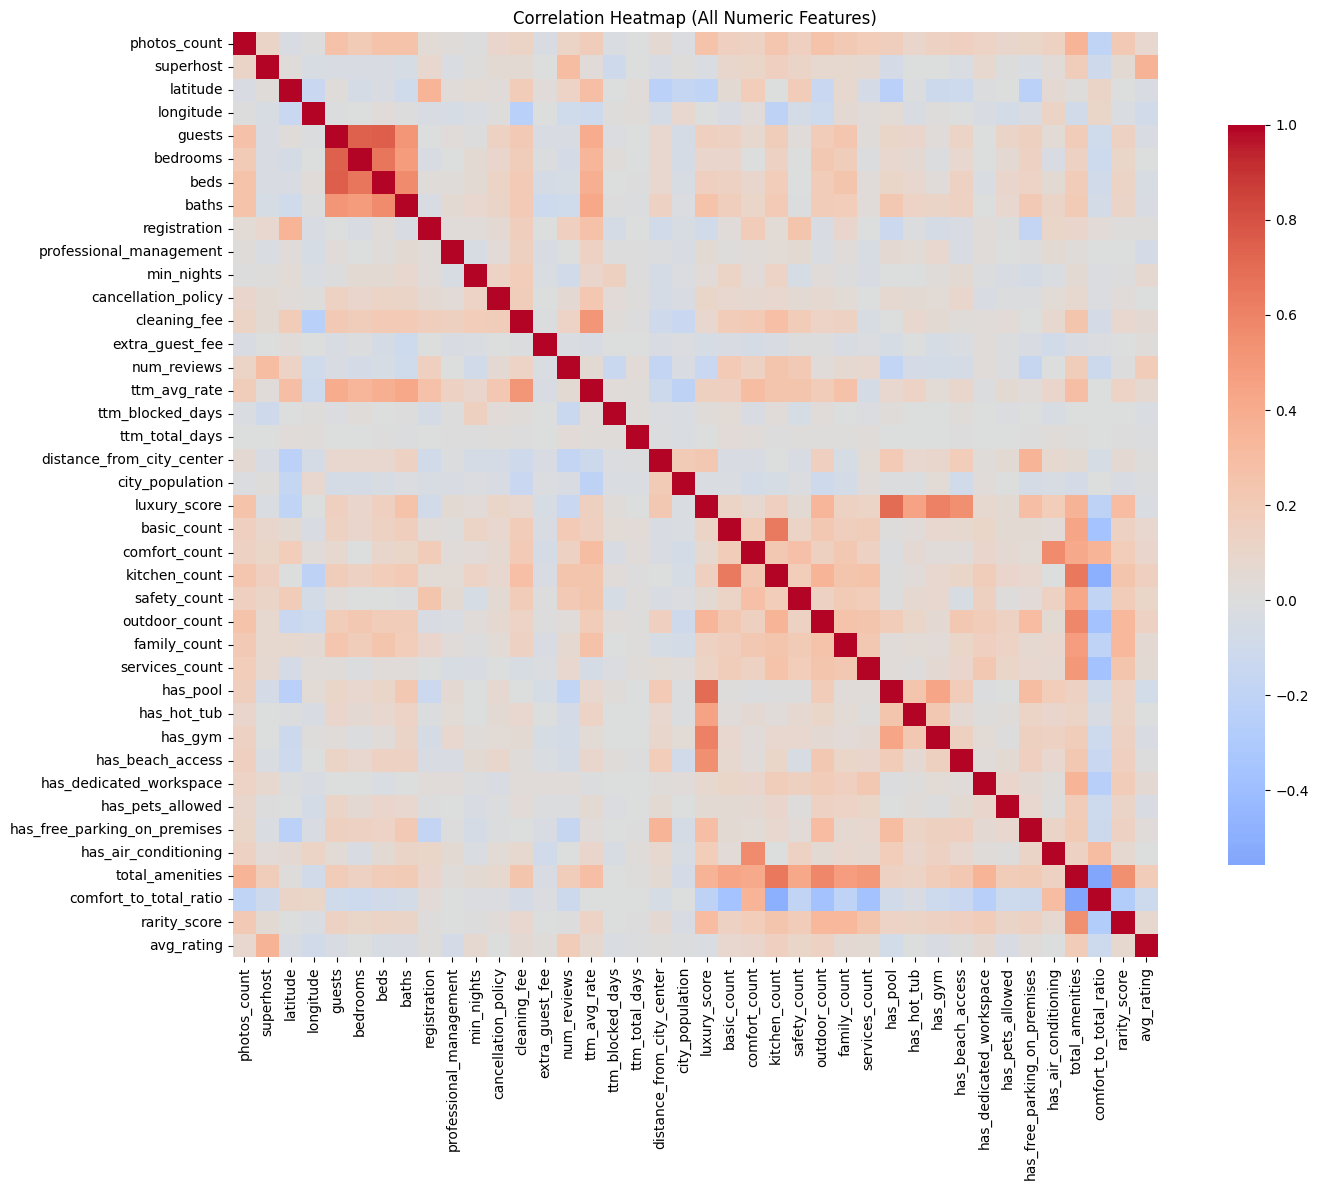

In [42]:
# Plot correlation heatmap on all numeric features
numeric_df = df_encoded.select_dtypes(include=[np.number]).copy()
corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, annot=False, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (All Numeric Features)")
plt.tight_layout()
plt.show()

### Step 10. Save the feature engineered dataset

In [43]:
df_encoded.to_csv(output_path, index=False)
print(f"Final engineered shape: {df_encoded.shape}")
print(f"Saved engineered data to: {output_path}")

df_encoded.head(3)

Final engineered shape: (37293, 61)
Saved engineered data to: c:\Users\RUSHIKESH\Desktop\Airbnb Project\data\processed\main\feature_engineered.csv


,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,registration,professional_management,...,room_type_entire_home,room_type_hotel_room,room_type_private_room,room_type_shared_room,geographic_zone_Africa,geographic_zone_Asia Pacific,geographic_zone_Europe,geographic_zone_Latin America,geographic_zone_Middle East,geographic_zone_Northern America
0,34.0,1,5.5733,-0.1960,2.0,1.0,1.0,1.5,0,0,...,True,False,False,False,True,False,False,False,False,False
1,14.0,0,5.5860,-0.1673,2.0,2.0,2.0,1.0,0,0,...,True,False,False,False,True,False,False,False,False,False
2,10.0,1,5.5610,-0.1856,2.0,1.0,1.0,1.0,0,0,...,True,False,False,False,True,False,False,False,False,False


In [44]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 37293 entries, 0 to 47809
Data columns (total 61 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   photos_count                      37293 non-null  float64
 1   superhost                         37293 non-null  int64  
 2   latitude                          37293 non-null  float64
 3   longitude                         37293 non-null  float64
 4   guests                            37293 non-null  float64
 5   bedrooms                          37293 non-null  float64
 6   beds                              37293 non-null  float64
 7   baths                             37293 non-null  float64
 8   registration                      37293 non-null  int64  
 9   professional_management           37293 non-null  int64  
 10  min_nights                        37293 non-null  float64
 11  cancellation_policy               37293 non-null  int64  
 12  cleaning_fee        